In [ ]:
!pip install unsloth   -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 213.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 130.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 168.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 189.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 181.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.

In [ ]:

!pip install --upgrade --no-cache-dir --no-deps "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!pip install --no-deps trl peft accelerate bitsandbytes -q

In [ ]:
!pip install datasets matplotlib  -q

## Mount  Drive in Colab Content /

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import math

In [ ]:
import gc
import json
import os
import shutil
import time
from pathlib import Path

In [ ]:
import torch

## Check Hardware

In [ ]:

print(torch.cuda.get_device_name(0))
print("bf16 available", torch.cuda.is_bf16_supported())

NVIDIA RTX PRO 6000 Blackwell Server Edition
bf16 available True


In [ ]:
print(f"torch {torch.__version__}")
print(f"device: {torch.cuda.get_device_name(0)}")
print(f"bf16 supported: {torch.cuda.is_bf16_supported()}")

torch 2.11.0+cu128
device: NVIDIA RTX PRO 6000 Blackwell Server Edition
bf16 supported: True


In [ ]:
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
MAX_SEQ_LENGTH = 1024

In [ ]:
# Drive paths ( source of truth + final destination )
DRIVE_BASE = "/content/drive/MyDrive/aegis-geo-mind"
DRIVE_MASTER = f"{DRIVE_BASE}/aegis_geo_mind_master"
DRIVE_TRAIN = f"{DRIVE_MASTER}/aegis_geo_mind_train_final.jsonl"
DRIVE_VAL = f"{DRIVE_MASTER}/aegis_geo_mind_val_final.jsonl"
DRIVE_TEST = f"{DRIVE_MASTER}/geology_test.json"
DRIVE_MODEL_OUT = f"{DRIVE_BASE}/model"

In [ ]:
# Local paths under /content (where ALL work happens)
LOCAL_BASE = "/content/aegis_geo_mind_run"
LOCAL_TRAIN = f"{LOCAL_BASE}/train.jsonl"
LOCAL_VAL = f"{LOCAL_BASE}/val.jsonl"
LOCAL_TEST = f"{LOCAL_BASE}/geology_test.json"
LOCAL_CKPT = f"{LOCAL_BASE}/checkpoints"

## Hpyerparameters

In [ ]:
EPOCHS = 3
PER_DEVICE_BATCH = 8
GRAD_ACCUM = 4
LEARNING_RATE = 2e-4
WARMUP_RATIO = 0.03
WEIGHT_DECAY = 0.01
LR_SCHEDULER = "cosine"

In [ ]:
EVAL_STEPS = 250
SAVE_STEPS = 250
LOGGING_STEPS = 20
SAVE_TOTAL_LIMIT = 2
EARLY_STOPPING_PATIENCE = 3

In [ ]:
EVAL_SUBSET = 450

In [ ]:
# LORA
LORA_R = 16
LORA_ALPHA = 16
LORA_DROPOUT = 0.0
LORA_TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj",
]

In [ ]:
SEED = 42

In [ ]:
Path(LOCAL_BASE).mkdir(parents=True, exist_ok=True)
Path(LOCAL_CKPT).mkdir(parents=True, exist_ok=True)

In [ ]:
for _src, _dst in [(DRIVE_TRAIN, LOCAL_TRAIN),
                   (DRIVE_VAL, LOCAL_VAL),
                   (DRIVE_TEST, LOCAL_TEST)]:
    if not os.path.exists(_src):
        raise FileNotFoundError(f"Missing on Drive: {_src}")
    shutil.copy2(_src, _dst)
    print(f"  copied: {_src} -> {_dst}")


  copied: /content/drive/MyDrive/aegis-geo-mind/aegis_geo_mind_master/aegis_geo_mind_train_final.jsonl -> /content/aegis_geo_mind_run/train.jsonl
  copied: /content/drive/MyDrive/aegis-geo-mind/aegis_geo_mind_master/aegis_geo_mind_val_final.jsonl -> /content/aegis_geo_mind_run/val.jsonl
  copied: /content/drive/MyDrive/aegis-geo-mind/aegis_geo_mind_master/geology_test.json -> /content/aegis_geo_mind_run/geology_test.json


In [ ]:
def count_valid(path):
    """Count valid JSON records. Handles both JSONL and JSON-array files."""
    content = Path(path).read_text(encoding="utf-8").strip()
    if content and content[0] == "[":
        return len(json.loads(content))
    n = 0
    for line in content.splitlines():
        if line.strip():
            json.loads(line)
            n += 1
    return n


In [ ]:
n_train = count_valid(LOCAL_TRAIN)
n_val = count_valid(LOCAL_VAL)
n_test = count_valid(LOCAL_TEST)
print(f"\nIntegrity check: train={n_train}, val={n_val}, test={n_test}")


Integrity check: train=21639, val=940, test=60


In [ ]:
from unsloth import FastLanguageModel

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,           # auto (bf16 on Blackwell)
    load_in_4bit=True,    # QLoRA
)

==((====))==  Unsloth 2026.7.5: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    target_modules=LORA_TARGET_MODULES,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
)

Unsloth 2026.7.5 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


In [ ]:
_total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"VRAM total: {_total_vram:.1f} GB")
print(f"VRAM reserved after load: {torch.cuda.memory_reserved()/1e9:.1f} GB")


VRAM total: 102.0 GB
VRAM reserved after load: 7.4 GB


In [ ]:
# Build the train / eval datasets from LOCAL files
# val is subsampled: eval loss is a trend indicator, 300 rows tracks the
# curve as well as the full set at a fraction of the time.

In [ ]:
from transformers import TrainerCallback

In [ ]:
from datasets import load_dataset

In [ ]:
train_ds = load_dataset("json", data_files=LOCAL_TRAIN, split="train")
val_ds = load_dataset("json", data_files=LOCAL_VAL, split="train")

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
if EVAL_SUBSET and EVAL_SUBSET < len(val_ds):
    val_ds = val_ds.shuffle(seed=SEED).select(range(EVAL_SUBSET))
    print(f"val subsampled to {len(val_ds)} rows for fast eval")


val subsampled to 450 rows for fast eval


In [ ]:
def format_chat(example):
    """Render a ChatML example into a single training string using the
    model's own chat template."""
    text = tokenizer.apply_chat_template(
        example["messages"], tokenize=False, add_generation_prompt=False
    )
    return {"text": text}


In [ ]:
train_ds = train_ds.map(format_chat, remove_columns=train_ds.column_names)
val_ds = val_ds.map(format_chat, remove_columns=val_ds.column_names)
print(f"train: {len(train_ds)} rows, eval: {len(val_ds)} rows")


Map:   0%|          | 0/21639 [00:00<?, ? examples/s]

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

train: 21639 rows, eval: 450 rows


In [ ]:
import random

In [ ]:
class DynamicValSubsetCallback(TrainerCallback):
    """Randomly sample a subset of val examples on each eval."""
    def __init__(self, val_ds, subset_size, seed):
        self.val_ds = val_ds
        self.subset_size = subset_size
        self.seed = seed
        self.rng = random.Random(seed)

    def on_evaluate(self, args, state, control, **kwargs):
        if self.subset_size and self.subset_size < len(self.val_ds):
            indices = self.rng.sample(range(len(self.val_ds)), self.subset_size)
            subset_ds = self.val_ds.select(indices)
            control.eval_dataset = subset_ds
            print(f"Eval on {len(subset_ds)} randomly sampled val examples")

val_subset_callback = DynamicValSubsetCallback(val_ds, EVAL_SUBSET, SEED)

In [ ]:
val_subset_callback = DynamicValSubsetCallback(val_ds, EVAL_SUBSET, SEED)

In [ ]:
# Build Trainer
# All I/O local. Eval and save on the same cadence (250) so early stopping
# <It> has enough resolution across the ~2000-step run.

In [ ]:

from trl import SFTTrainer, SFTConfig
from transformers import EarlyStoppingCallback

In [ ]:

sft_config = SFTConfig(
    per_device_train_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    per_device_eval_batch_size=PER_DEVICE_BATCH,

    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_type=LR_SCHEDULER,
    optim="adamw_8bit",
    bf16=True,

    output_dir=LOCAL_CKPT,
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    save_total_limit=SAVE_TOTAL_LIMIT,

    eval_strategy="steps",
    eval_steps=EVAL_STEPS,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    logging_steps=LOGGING_STEPS,
    seed=SEED,
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_text_field="text",
    report_to="none",
    dataloader_num_workers=4,
    dataloader_pin_memory=True,
)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    args=sft_config,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE),
        val_subset_callback,
    ],
)

Unsloth: Tokenizing ["text"] (num_proc=52):   0%|          | 0/21639 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=52):   0%|          | 0/450 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [ ]:
torch.cuda.synchronize()
_t0 = time.time()

In [ ]:
train_result = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 21,639 | Num Epochs = 3 | Total steps = 2,031
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 4 x 1) = 32
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
250,1.559206,1.604696
500,1.420233,1.574467
750,1.231194,1.566285
1000,1.140760,1.562689
1250,1.140484,1.560052
1500,1.012291,1.575963
1750,1.052699,1.573643
2000,1.065553,1.573659


Unsloth: Restored added_tokens_decoder metadata in /content/aegis_geo_mind_run/checkpoints/checkpoint-250/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/aegis_geo_mind_run/checkpoints/checkpoint-500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/aegis_geo_mind_run/checkpoints/checkpoint-750/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/aegis_geo_mind_run/checkpoints/checkpoint-1000/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/aegis_geo_mind_run/checkpoints/checkpoint-1250/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/aegis_geo_mind_run/checkpoints/checkpoint-1500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/aegis_geo_mind_run/checkpoints/checkpoint-1750/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/aegis_geo_mind_run/checkpoints/ch

In [ ]:
torch.cuda.synchronize()
elapsed_seconds = time.time() - _t0

In [ ]:
train_runtime_min = elapsed_seconds / 60
train_runtime_h = elapsed_seconds / 3600
estimated_credits = train_runtime_h * 9

In [ ]:
print(f"\nTraining wall clock: {train_runtime_min:.1f} min ({train_runtime_h:.2f} h)")
print(f"Estimated credits consumed: ~{estimated_credits:.1f}")
print(f"Final train loss: {train_result.training_loss:.4f}")



Training wall clock: 40.0 min (0.67 h)
Estimated credits consumed: ~6.0
Final train loss: 1.2733


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
_train_steps, _train_loss = [], []
_eval_steps, _eval_loss = [], []

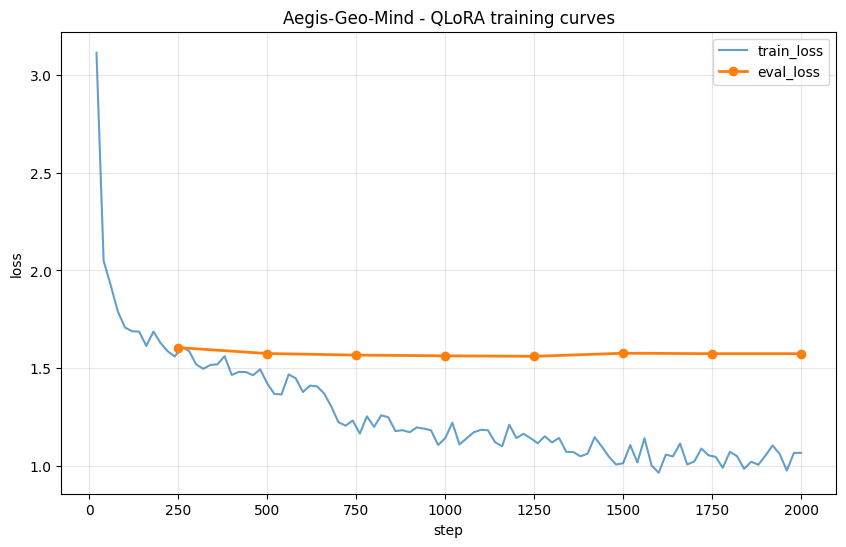

In [ ]:

for h in trainer.state.log_history:
    if "loss" in h and "step" in h:
        _train_steps.append(h["step"])
        _train_loss.append(h["loss"])
    if "eval_loss" in h and "step" in h:
        _eval_steps.append(h["step"])
        _eval_loss.append(h["eval_loss"])

plt.figure(figsize=(10, 6))
plt.plot(_train_steps, _train_loss, label="train_loss", alpha=0.7)
if _eval_steps:
    plt.plot(_eval_steps, _eval_loss, label="eval_loss", marker="o", linewidth=2)
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Aegis-Geo-Mind - QLoRA training curves")
plt.legend()
plt.grid(True, alpha=0.3)

plot_path = f"{LOCAL_BASE}/training_curves.png"
plt.savefig(plot_path, dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
best_eval_loss = min(_eval_loss) if _eval_loss else None
print(f"Best eval_loss: {best_eval_loss}")


Best eval_loss: 1.5600515604019165


In [ ]:
from unsloth import FastLanguageModel

In [ ]:
FastLanguageModel.for_inference(model)
print("Model in inference mode.")


Model in inference mode.


In [ ]:

def load_flexible(path):
    """Load a JSON-array or JSONL file into a list of dicts."""
    text = Path(path).read_text(encoding="utf-8").strip()
    if not text:
        return []
    if text[0] == "[":
        return json.loads(text)
    return [json.loads(l) for l in text.splitlines() if l.strip()]



In [ ]:
test_data = load_flexible(LOCAL_TEST)
print(f"Test set: {len(test_data)} examples")


Test set: 60 examples


In [ ]:
_total_loss = 0.0
_n_scored = 0
test_samples = []


In [ ]:
for _i, _ex in enumerate(test_data):
    _messages = _ex["messages"]
    _target = _messages[-1]["content"]
    _prompt_msgs = _messages[:-1]

    # (1) greedy generation
    _prompt_text = tokenizer.apply_chat_template(
        _prompt_msgs, tokenize=False, add_generation_prompt=True
    )
    _inputs = tokenizer(_prompt_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        _gen = model.generate(
            **_inputs, max_new_tokens=256, do_sample=False,
            temperature=None, top_p=None,
            pad_token_id=tokenizer.eos_token_id,
        )
    _gen_text = tokenizer.decode(
        _gen[0][_inputs["input_ids"].shape[1]:], skip_special_tokens=True
    )

    # (2) teacher-forced loss on the reference answer only
    _full_text = tokenizer.apply_chat_template(
        _messages, tokenize=False, add_generation_prompt=False
    )
    _full_ids = tokenizer(_full_text, return_tensors="pt").to(model.device)
    _prompt_ids = tokenizer(_prompt_text, return_tensors="pt").to(model.device)
    _prompt_len = _prompt_ids["input_ids"].shape[1]

    _labels = _full_ids["input_ids"].clone()
    _labels[:, :_prompt_len] = -100
    with torch.no_grad():
        _out = model(**_full_ids, labels=_labels)
    if not math.isnan(_out.loss.item()):
        _total_loss += _out.loss.item()
        _n_scored += 1

    test_samples.append({
        "question": _prompt_msgs[-1]["content"],
        "reference": _target,
        "generated": _gen_text,
    })

In [ ]:
test_avg_loss = _total_loss / _n_scored if _n_scored else float("nan")
test_perplexity = math.exp(test_avg_loss) if test_avg_loss == test_avg_loss else float("nan")

In [ ]:
print(f"Test avg loss (reference answers): {test_avg_loss:.4f}")
print(f"Test perplexity: {test_perplexity:.2f}")


Test avg loss (reference answers): 1.8119
Test perplexity: 6.12


In [ ]:
for _s in test_samples:
    print("-" * 60)
    print(f"Q:   {_s['question'][:150]}")
    print(f"REF: {_s['reference'][:200]}")
    print(f"GEN: {_s['generated'][:200]}")



------------------------------------------------------------
Q:   What are the three main types of rocks?
REF: The three main types of rocks are igneous, sedimentary, and metamorphic. Igneous rocks form from the cooling of magma or lava. Sedimentary rocks are created from the accumulation and lithification of 
GEN: The three main types of rocks are igneous, sedimentary, and metamorphic. 

Igneous rocks form from cooled magma or lava. They can be intrusive (formed below the surface) or extrusive (formed above the
------------------------------------------------------------
Q:   What are the primary layers of the Earth's interior?
REF: The Earth is divided into four primary layers: the solid outer crust, the viscous and semi-solid mantle, the liquid outer core (mostly iron and nickel), and the solid inner core.
GEN: The Earth's interior is divided into several layers, including:

1. Crust: The outermost layer of the Earth, which is about 30-50 km thick and composed mainly of silicate roc

In [ ]:
for _s in test_samples:
    print("-" * 60)
    print(f"Q:   {_s['question'][:150]}")
    print(f"REF: {_s['reference'][:200]}")
    print(f"GEN: {_s['generated'][:200]}")


In [ ]:
# Inspect domain-specific generations (petroleum / stratigraphy / logging / seismic)

DOMAIN_KEYWORDS = [
    "reservoir", "petroleum", "oil", "gas", "source rock", "seal", "trap",
    "stratigraph", "sequence", "facies", "depositional", "sediment",
    "well log", "wireline", "gamma ray", "porosity", "permeability",
    "seismic", "structural", "fault", "basin", "migration", "maturation",
    "turbidite", "fluvial", "deltaic", "carbonate", "clastic",
    "cuenca", "reservorio", "estratigraf", "sismica", "petrol",
]

In [ ]:
def is_domain_question(text):
    """True if the question text mentions any core-domain keyword."""
    low = text.lower()
    return any(kw in low for kw in DOMAIN_KEYWORDS)

In [ ]:

domain_results = []
for _ex in test_data:
    _messages = _ex["messages"]
    _prompt_msgs = _messages[:-1]
    _question = _prompt_msgs[-1]["content"]
    if not is_domain_question(_question):
        continue

    _prompt_text = tokenizer.apply_chat_template(
        _prompt_msgs, tokenize=False, add_generation_prompt=True
    )
    _inputs = tokenizer(_prompt_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        _gen = model.generate(
            **_inputs, max_new_tokens=400, do_sample=False,
            temperature=None, top_p=None,
            pad_token_id=tokenizer.eos_token_id,
        )
    _gen_text = tokenizer.decode(
        _gen[0][_inputs["input_ids"].shape[1]:], skip_special_tokens=True
    )
    domain_results.append({
        "question": _question,
        "reference": _messages[-1]["content"],
        "generated": _gen_text,
    })


In [ ]:
## Double check model answers .  it was good, never perfect,  it will be fixed by a futrue version Geology RAG

In [ ]:
print(f"Found {len(domain_results)} domain-specific questions in the test set\n")
for _r in domain_results:
    print("=" * 70)
    print(f"Q:   {_r['question']}")
    print(f"\nREF: {_r['reference']}")
    print(f"\nGEN: {_r['generated']}")
    print()

Both `max_new_tokens` (=400) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=4

Found 34 domain-specific questions in the test set

Q:   How are sedimentary rocks typically layered?

REF: Sedimentary rocks are typically laid down in horizontal layers called strata or beds. The Law of Superposition states that in an undisturbed sequence, the oldest layers are at the bottom and the youngest are at the top.

GEN: Sedimentary rocks are typically layered, with each layer representing a different type of sediment or rock that was deposited over time. These layers can be horizontal, vertical, or even diagonal, depending on the angle at which the sediment was deposited. The layers can also vary in thickness and composition, with some layers being thicker or made up of different types of sediment than others. This layering is known as bedding, and it is used to identify and map the different layers of sedimentary rocks.

Q:   How does sequence stratigraphy apply to basin analysis?

REF: Sequence stratigraphy subdivides sedimentary basin deposits into genetic units bounded 

In [ ]:
metrics = {
    "n_train": n_train,
    "n_val": n_val,
    "n_test": n_test,
    "train_runtime_min": train_runtime_min,
    "train_runtime_h": train_runtime_h,
    "estimated_credits": estimated_credits,
    "final_train_loss": train_result.training_loss,
    "best_eval_loss": best_eval_loss,
    "test_avg_loss": test_avg_loss,
    "test_perplexity": test_perplexity,
}


In [ ]:
print("=== FINAL METRICS ===")
for _k, _v in metrics.items():
    print(f"  {_k}: {_v}")


=== FINAL METRICS ===
  n_train: 21639
  n_val: 940
  n_test: 60
  train_runtime_min: 39.961214172840116
  train_runtime_h: 0.666020236214002
  estimated_credits: 5.9941821259260175
  final_train_loss: 1.2733108272552491
  best_eval_loss: 1.5600515604019165
  test_avg_loss: 1.8119087984164557
  test_perplexity: 6.122122183441642


In [ ]:
local_final = f"{LOCAL_BASE}/best_model"
model.save_pretrained(local_final)
tokenizer.save_pretrained(local_final)

Unsloth: Restored added_tokens_decoder metadata in /content/aegis_geo_mind_run/best_model/tokenizer_config.json.


('/content/aegis_geo_mind_run/best_model/tokenizer_config.json',
 '/content/aegis_geo_mind_run/best_model/chat_template.jinja',
 '/content/aegis_geo_mind_run/best_model/tokenizer.json')

In [ ]:
with open(f"{local_final}/aegis_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print(f"Saved locally: {local_final}")


Saved locally: /content/aegis_geo_mind_run/best_model


In [ ]:
Path(DRIVE_MODEL_OUT).mkdir(parents=True, exist_ok=True)
shutil.copytree(local_final, DRIVE_MODEL_OUT, dirs_exist_ok=True)
shutil.copy2(plot_path, f"{DRIVE_BASE}/training_curves.png")



'/content/drive/MyDrive/aegis-geo-mind/training_curves.png'

In [ ]:
_files = os.listdir(DRIVE_MODEL_OUT)
print(f"Uploaded to Drive: {DRIVE_MODEL_OUT}")
print(f"Files present ({len(_files)}): {_files}")

Uploaded to Drive: /content/drive/MyDrive/aegis-geo-mind/model
Files present (7): ['adapter_model.safetensors', 'tokenizer_config.json', 'chat_template.jinja', 'adapter_config.json', 'README.md', 'aegis_metrics.json', 'tokenizer.json']
